# Занятие 1. Переход от учебных данных к реальному датасету из интернета

## Зачем этот ноутбук
На прошлых занятиях блока аналитики мы работали с тестовыми данными, которые сами генерировали в Python и затем сохраняли в Excel.  
Теперь задача меняется: **мы учимся брать реальные открытые данные из интернета**, анализировать их и делать выводы.

## Связь с дипломным проектом
В рамках дипломного проекта вам нужно будет:

1. определить тему проекта;
2. найти **реальный датасет** по этой теме;
3. загрузить его в Python;
4. провести первичный анализ данных;
5. сделать содержательные выводы;
6. объяснить, чем этот анализ полезен для вашей темы.

## Что вы освоите в этом ноутбуке
- загрузку датасета по URL;
- первичный анализ структуры данных;
- создание новых аналитических признаков;
- группировку и агрегирование;
- визуализацию;
- формулирование выводов на основе данных.

## Краткая теория
Работа с реальным датасетом обычно идёт по такому алгоритму:

1. **Найти источник данных** и понять, кто его публикует.
2. **Прочитать описание датасета**: что означает каждая колонка, какие единицы измерения, за какой период собраны данные.
3. **Загрузить данные** в Python.
4. **Посмотреть структуру**: размер, типы столбцов, пропуски, примеры строк.
5. **Подготовить данные**: выбрать нужный срез, создать вычисляемые столбцы, убрать лишнее.
6. **Ответить на несколько вопросов к данным**.
7. **Сделать выводы** и связать их с задачей проекта.

---

## Датасет для демонстрации
В этом уроке используется публичный CSV-файл, доступный по URL.  
Мы загрузим его напрямую из интернета и выполним мини-анализ.

Тематика датасета:
- страны мира
- население
- ожидаемая продолжительность жизни
- ВВП на душу населения
- динамика по годам

Это хороший пример, потому что он:
- небольшой и удобный для первого знакомства;
- позволяет делать понятные аналитические выводы;
- показывает, как из открытых данных получать осмысленный результат.

## Практическая ячейка 1. Импорт библиотек и загрузка датасета по URL

### Что делает эта ячейка
- подключает библиотеки `pandas` и `matplotlib`;
- задаёт ссылку на CSV-файл в интернете;
- загружает датасет в DataFrame;
- показывает первые строки таблицы.

### Краткий алгоритм
1. Импортировать библиотеки.
2. Сохранить URL датасета в переменную.
3. Прочитать CSV через `pd.read_csv(...)`.
4. Сохранить результат в переменную `df`.
5. Вывести первые строки через `head()`.

### Функции, методы и синтаксис
- `import pandas as pd` — подключение библиотеки Pandas.
- `import matplotlib.pyplot as plt` — библиотека для графиков.
- `pd.read_csv(url)` — чтение CSV по ссылке или из файла.
- `df.head()` — показать первые 5 строк таблицы.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# URL открытого датасета
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

try:
    # Основной вариант: загружаем данные из интернета
    df = pd.read_csv(url)
    print("Данные успешно загружены из интернета.")
except Exception as e:
    # Резервный вариант: локальная копия файла
    print("Не удалось загрузить данные из интернета. Используется локальная копия.")
    print("Техническая причина:", e)
    df = pd.read_csv("gapminderDataFiveYear.csv")

print("Размер таблицы:", df.shape)
df.head()

Данные успешно загружены из интернета.
Размер таблицы: (1704, 6)


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## Практическая ячейка 2. Первичный обзор данных

### Что делает эта ячейка
- показывает названия столбцов;
- показывает типы данных;
- выводит общую информацию о таблице;
- считает базовую статистику по числовым столбцам.

### Краткий алгоритм
1. Посмотреть названия колонок.
2. Проверить типы данных.
3. Выполнить `info()`.
4. Выполнить `describe()`.
5. Зафиксировать первые наблюдения.

### Функции, методы и синтаксис
- `df.columns` — список имён столбцов.
- `df.dtypes` — типы данных по столбцам.
- `df.info()` — обзор структуры таблицы.
- `df.describe()` — числовая статистика: среднее, минимум, максимум и т.д.

In [ ]:
print("Названия столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
print(df.dtypes)

print("\nПояснение типов данных:")
print("  - country (страна): object (строковый тип, текст)")
print("  - year (год): int64 (целое число)")
print("  - pop (население): float64 (число с плавающей точкой)")
print("  - continent (континент): object (строковый тип, текст)")
print("  - lifeExp (ожидаемая продолжительность жизни): float64 (число с плавающей точкой)")
print("  - gdpPercap (ВВП на душу населения): float64 (число с плавающей точкой)")

print("\nОбщая информация:")
df.info()

print("\nОписательная статистика:")
df.describe()

Названия столбцов:
['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap']

Типы данных:
country       object
year           int64
pop          float64
continent     object
lifeExp      float64
gdpPercap    float64
dtype: object

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB

Описательная статистика:


,year,pop,lifeExp,gdpPercap
count,1704.00000,1.704000e+03,1704.000000,1704.000000
mean,1979.50000,2.960121e+07,59.474439,7215.327081
std,17.26533,1.061579e+08,12.917107,9857.454543
min,1952.00000,6.001100e+04,23.599000,241.165876
25%,1965.75000,2.793664e+06,48.198000,1202.060309
50%,1979.50000,7.023596e+06,60.712500,3531.846988
75%,1993.25000,1.958522e+07,70.845500,9325.462346
max,2007.00000,1.318683e+09,82.603000,113523.132900


Пояснения по строкам:

count (Количество): Показывает количество непустых значений для каждого столбца. В нашем случае, для всех столбцов 1704, что означает отсутствие пропусков в этих числовых данных. Это хорошо, так как нам не нужно будет заниматься их заполнением.
mean (Среднее значение): Это среднее арифметическое всех значений в столбце.
Средний год наблюдения: 1979.5.
Среднее население: около 29.6 миллионов человек. (Обратите внимание на e+07 — это экспоненциальная запись, означающая 10 в степени 7).
Средняя ожидаемая продолжительность жизни: около 59.47 лет.
Средний ВВП на душу населения: около $7215.33.
std (Стандартное отклонение): Показывает, насколько значения в столбце отклоняются от среднего. Чем больше стандартное отклонение, тем шире разброс данных.
Население (pop) имеет очень высокое стандартное отклонение (1.06e+08), что говорит о значительном разбросе в численности населения между странами, от очень маленьких до очень больших.
gdpPercap также имеет высокое стандартное отклонение (9857), указывая на большую разницу в уровне экономического развития.
min (Минимальное значение): Самое низкое значение в столбце.
Минимальное население: 60,011 человек.
Минимальная продолжительность жизни: 23.599 лет (это очень низкий показатель).
Минимальный ВВП на душу населения: $241.17.
25% (Первый квартиль): Это значение, ниже которого находится 25% всех данных. Его еще называют Q1.
50% (Медиана): Это середина данных, если их отсортировать. 50% значений меньше медианы, и 50% больше. Медиана часто более устойчива к выбросам, чем среднее.
Медианная продолжительность жизни (60.71 лет) немного выше среднего (59.47), что может указывать на небольшой левосторонний перекос в распределении (больше стран с продолжительностью жизни ниже среднего, чем с продолжительностью жизни сильно выше среднего).
75% (Третий квартиль): Это значение, ниже которого находится 75% всех данных. Его еще называют Q3.
max (Максимальное значение): Самое высокое значение в столбце.
Максимальное население: около 1.3 миллиарда человек.
Максимальная продолжительность жизни: 82.603 года.
Максимальный ВВП на душу населения: $113,523.13.
Ключевые выводы из этой статистики:

Широкий диапазон данных: Население и ВВП на душу населения имеют огромный разброс значений (особенно заметно по min и max, а также по std), что логично для данных по разным странам мира.
Продолжительность жизни: Средняя продолжительность жизни составляет около 59 лет, но есть страны как с очень низкой (23 года), так и с очень высокой (82 года) продолжительностью жизни.
Отсутствие пропусков: Все числовые столбцы имеют одинаковое количество записей (1704), что указывает на отсутствие пропущенных значений в этих колонках.

## Практическая ячейка 3. Подготовка данных для анализа

### Что делает эта ячейка
- проверяет пропуски;
- выбирает данные только за 2007 год;
- создаёт новый столбец `gdp_total_est`, который оценивает общий ВВП как произведение населения на ВВП на душу населения.

### Краткий алгоритм
1. Проверить количество пропусков.
2. Отфильтровать таблицу по нужному году.
3. Создать копию выборки.
4. Добавить новый вычисляемый столбец.
5. Посмотреть результат.

### Функции, методы и синтаксис
- `df.isna().sum()` — количество пропусков по столбцам.
- `df[df["year"] == 2007]` — фильтрация строк по условию.
- `.copy()` — создание независимой копии DataFrame.
- `df["new_col"] = ...` — создание нового столбца.

In [ ]:
print("Количество пропусков по столбцам:")
print(df.isna().sum())

# Берём один временной срез, чтобы анализ был понятнее
df_2007 = df[df["year"] == 2007].copy()

# Пример вычисляемого признака
df_2007["gdp_total_est"] = df_2007["pop"] * df_2007["gdpPercap"]

print("\nРазмер выборки за 2007 год:", df_2007.shape)
df_2007.head()

Количество пропусков по столбцам:
country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64

Размер выборки за 2007 год: (142, 7)


,country,year,pop,continent,lifeExp,gdpPercap,gdp_total_est
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338,3.107929e+10
23,Albania,2007,3600523.0,Europe,76.423,5937.029526,2.137641e+10
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465,2.074449e+11
47,Angola,2007,12420476.0,Africa,42.731,4797.231267,5.958390e+10
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640,5.150336e+11


## Практическая ячейка 4. Анализ: группировка, агрегаты и поиск лидеров

### Что делает эта ячейка
- строит сводную таблицу по континентам;
- считает среднюю продолжительность жизни;
- считает медианный ВВП на душу населения;
- считает суммарное население и оценочный общий ВВП;
- показывает страны-лидеры по ключевым показателям.

### Краткий алгоритм
1. Сгруппировать строки по континенту.
2. Применить агрегатные функции.
3. Отсортировать результат.
4. Найти топ стран по продолжительности жизни.
5. Найти топ стран по оценочному общему ВВП.

### Функции, методы и синтаксис
- `groupby(...)` — группировка по признаку.
- `agg(...)` — применение набора агрегатных функций.
- `sort_values(...)` — сортировка.
- `nlargest(...)` — выбор строк с наибольшими значениями.

этот код создает сводную таблицу, которая показывает среднюю продолжительность жизни, медианный ВВП на душу населения, общую численность населения и общий оценочный ВВП для каждого континента в 2007 году, отсортированную по средней продолжительности жизни

In [ ]:
continent_summary = (
    df_2007
    .groupby("continent")
    .agg(
        avg_lifeExp=("lifeExp", "mean"),
        median_gdpPercap=("gdpPercap", "median"),
        total_population=("pop", "sum"),
        total_gdp_est=("gdp_total_est", "sum")
    )
    .sort_values("avg_lifeExp", ascending=False)
)

top_life = df_2007.nlargest(10, "lifeExp")[["country", "continent", "lifeExp"]]
top_gdp_total = df_2007.nlargest(10, "gdp_total_est")[["country", "continent", "gdp_total_est"]]

print("Сводка по континентам:")
display(continent_summary)

print("\nТоп-10 стран по ожидаемой продолжительности жизни:")
display(top_life)

print("\nТоп-10 стран по оценочному общему ВВП:")
display(top_gdp_total)

Сводка по континентам:


,avg_lifeExp,median_gdpPercap,total_population,total_gdp_est
continent,,,,
Oceania,80.719500,29810.188275,2.454995e+07,8.073141e+11
Europe,77.648600,28054.065790,5.860985e+08,1.479550e+13
Americas,73.608120,8948.102923,8.988712e+08,1.941809e+13
Asia,70.728485,4471.061906,3.811954e+09,2.070795e+13
Africa,54.806038,1452.267078,9.295397e+08,2.380486e+12



Топ-10 стран по ожидаемой продолжительности жизни:


,country,continent,lifeExp
803,Japan,Asia,82.603
671,"Hong Kong, China",Asia,82.208
695,Iceland,Europe,81.757
1487,Switzerland,Europe,81.701
71,Australia,Oceania,81.235
1427,Spain,Europe,80.941
1475,Sweden,Europe,80.884
767,Israel,Asia,80.745
539,France,Europe,80.657
251,Canada,Americas,80.653



Топ-10 стран по оценочному общему ВВП:


,country,continent,gdp_total_est
1619,United States,Americas,1.293446e+13
299,China,Asia,6.539501e+12
803,Japan,Asia,4.035135e+12
707,India,Asia,2.722925e+12
575,Germany,Europe,2.650871e+12
1607,United Kingdom,Europe,2.017969e+12
539,France,Europe,1.861228e+12
179,Brazil,Americas,1.722599e+12
779,Italy,Europe,1.661264e+12
995,Mexico,Americas,1.301973e+12


## Практическая ячейка 5. Визуализация и интерпретация

### Что делает эта ячейка
- строит столбчатую диаграмму средней продолжительности жизни по континентам;
- строит точечный график связи между ВВП на душу населения и продолжительностью жизни;
- помогает визуально увидеть закономерность.

### Краткий алгоритм
1. Построить агрегированный график по континентам.
2. Построить точечный график по странам.
3. Подписать оси и заголовки.
4. Сравнить регионы.
5. Сформулировать наблюдения.

### Функции, методы и синтаксис
- `plt.figure(...)` — создать область графика.
- `plt.bar(...)` — столбчатая диаграмма.
- `plt.scatter(...)` — точечный график.
- `plt.xticks(rotation=...)` — поворот подписей.
- `plt.grid(...)` — сетка на графике.
- `plt.show()` — показать график.

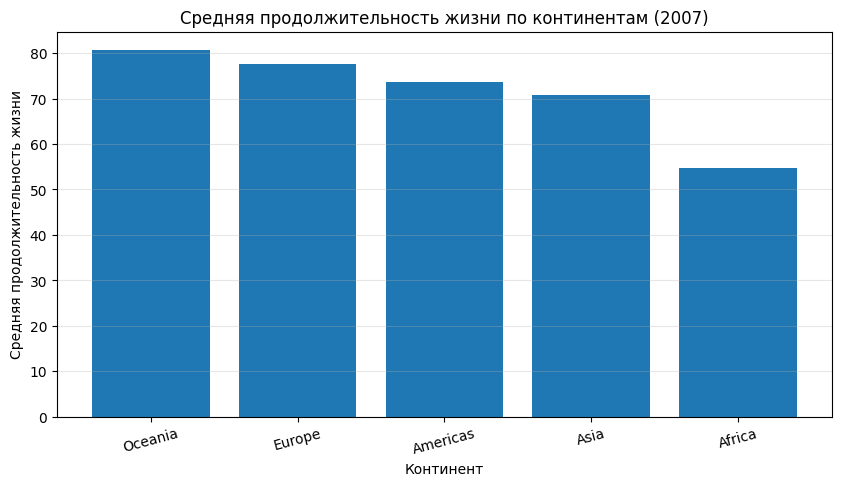

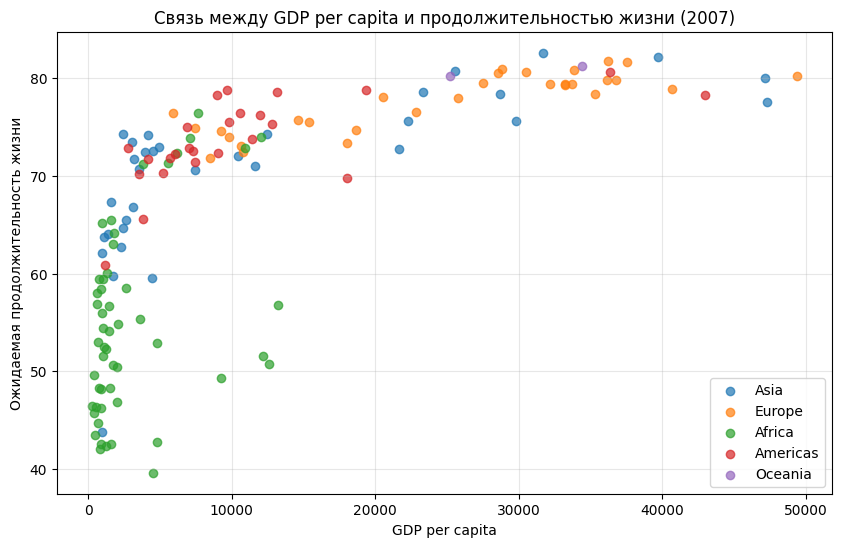

In [ ]:
# График 1. Средняя продолжительность жизни по континентам
plt.figure(figsize=(10, 5))
plt.bar(continent_summary.index, continent_summary["avg_lifeExp"])
plt.title("Средняя продолжительность жизни по континентам (2007)")
plt.xlabel("Континент")
plt.ylabel("Средняя продолжительность жизни")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.show()

# График 2. Связь между ВВП на душу населения и продолжительностью жизни
plt.figure(figsize=(10, 6))
for continent in df_2007["continent"].unique():
    part = df_2007[df_2007["continent"] == continent]
    plt.scatter(part["gdpPercap"], part["lifeExp"], label=continent, alpha=0.7)

plt.title("Связь между GDP per capita и продолжительностью жизни (2007)")
plt.xlabel("GDP per capita")
plt.ylabel("Ожидаемая продолжительность жизни")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Практическая ячейка 6. Выводы и мост к дипломному проекту

### Что делает эта ячейка
- формулирует несколько аналитических выводов по датасету;
- показывает, как связывать числа и графики с текстовым выводом;
- переводит студента от учебной практики к теме диплома.

### Краткий алгоритм
1. Взять 2–3 сильных наблюдения из таблиц и графиков.
2. Сформулировать их простым языком.
3. Связать выводы с задачей анализа данных.
4. Сформулировать следующее действие для дипломного проекта.

### Функции, методы и синтаксис
- `.idxmax()` — индекс строки с максимальным значением.
- `.max()` — максимальное значение.
- `print()` — вывод текста.
- `assert` — простая самопроверка результата.

In [ ]:
best_continent = continent_summary["avg_lifeExp"].idxmax()
best_life = continent_summary["avg_lifeExp"].max()

largest_total_gdp_country = df_2007.loc[df_2007["gdp_total_est"].idxmax(), "country"]

assert "gdp_total_est" in df_2007.columns
assert df_2007["year"].nunique() == 1
assert df_2007["year"].iloc[0] == 2007

print("Вывод 1:")
print(f"В 2007 году самый высокий средний уровень ожидаемой продолжительности жизни был в регионе: {best_continent} ({best_life:.2f}).")

print("\nВывод 2:")
print(f"Страна с наибольшим оценочным общим ВВП в этой выборке: {largest_total_gdp_country}.")

print("\nВывод 3:")
print("По точечному графику видно, что при росте GDP per capita часто растёт и ожидаемая продолжительность жизни,")
print("но зависимость не идеальна: на показатели влияют и другие факторы.")

print("\nЧто это значит для диплома:")
print("Для дипломного проекта нужно искать реальный датасет по вашей теме,")
print("проводить такой же первичный анализ и формулировать содержательные выводы, а не только показывать код.")

print("\nМини-задание студенту:")
print("1. Назовите тему своего дипломного проекта.")
print("2. Найдите 2 открытых источника данных по этой теме.")
print("3. Опишите, какие столбцы вы хотели бы анализировать.")
print("4. Сформулируйте 3 вопроса, на которые должен ответить анализ данных.")

Вывод 1:
В 2007 году самый высокий средний уровень ожидаемой продолжительности жизни был в регионе: Oceania (80.72).

Вывод 2:
Страна с наибольшим оценочным общим ВВП в этой выборке: United States.

Вывод 3:
По точечному графику видно, что при росте GDP per capita часто растёт и ожидаемая продолжительность жизни,
но зависимость не идеальна: на показатели влияют и другие факторы.

Что это значит для диплома:
Для дипломного проекта нужно искать реальный датасет по вашей теме,
проводить такой же первичный анализ и формулировать содержательные выводы, а не только показывать код.

Мини-задание студенту:
1. Назовите тему своего дипломного проекта.
2. Найдите 2 открытых источника данных по этой теме.
3. Опишите, какие столбцы вы хотели бы анализировать.
4. Сформулируйте 3 вопроса, на которые должен ответить анализ данных.


## Что студент должен вынести из этого занятия

После выполнения ноутбука вы должны понимать:

- тестовые данные удобны для изучения синтаксиса;
- для диплома нужны **реальные датасеты**;
- хороший аналитик не просто загружает таблицу, а отвечает на вопросы с помощью данных;
- результат анализа — это не только код, но и **понятные выводы**.

## Как действовать дальше
Для следующего шага по дипломному проекту подготовьте:
- тему проекта;
- 2–3 ссылки на открытые датасеты;
- краткое описание того, что именно в них можно анализировать.